<a href="https://colab.research.google.com/github/ks-chauhan/Brain-Tumor-Detection/blob/main/notebooks/CT_Scan_Segmentation_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
import shutil

src = "/content/drive/MyDrive/Brain Tumor/Brain Tumour CT Segmentation Dataset"
dst = "/content/ct_dataset"

shutil.copytree(src, dst)

FileExistsError: [Errno 17] File exists: '/content/ct_dataset'

In [103]:
data_dir = "/content/ct_dataset"
img_dir = data_dir + "/image"
mask_dir = data_dir + "/label"

In [115]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [116]:
# DATASET CLASS

import numpy as np
import os
from torch.utils.data import Dataset
from PIL import Image

class CTDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = []

        for img in sorted(os.listdir(img_dir)):
            mask_path = os.path.join(mask_dir, img)
            mask = np.array(Image.open(mask_path))

            if mask.sum() > 0:   # 🔥 KEEP ONLY NON-EMPTY
                self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0.5).float()

        return image, mask

In [117]:
# TRANSFORMER

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [118]:
# TRAIN/TEST SPLIT

from torch.utils.data import random_split

dataset = CTDataset(img_dir, mask_dir, transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [119]:
# LOADERS

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [120]:
# MODEL ARCHITECTURE

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = block(1,64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = block(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = block(128,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,2)
        self.dec2 = block(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,2)
        self.dec1 = block(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2,e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1,e1], dim=1))

        return self.out(d1)

In [121]:
# MODEL INITITALISATION

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [122]:
# LOSS

import torch.nn.functional as F

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6

    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def combined_loss(pred, target):
    return F.binary_cross_entropy_with_logits(pred, target) + dice_loss(pred, target)

In [123]:
# TRAINING LOOP

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 32.9211
Epoch 2, Loss: 24.3804
Epoch 3, Loss: 21.9832
Epoch 4, Loss: 16.6621
Epoch 5, Loss: 17.5925
Epoch 6, Loss: 14.2043
Epoch 7, Loss: 12.5938
Epoch 8, Loss: 13.0254
Epoch 9, Loss: 12.2642
Epoch 10, Loss: 12.0015


In [124]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions(model, dataset, device, num_samples=10):
    model.eval()

    fig, axes = plt.subplots(num_samples, 4, figsize=(12, 3 * num_samples))

    for i in range(num_samples):
        image, mask = dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.to(device)

        with torch.no_grad():
            output = model(image)
            pred = torch.sigmoid(output)
            pred = (pred > 0.3).float()

        # Convert to numpy
        img_np = image.squeeze().cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_np = pred.squeeze().cpu().numpy()

        # Overlay
        overlay = img_np.copy()
        overlay = overlay * 0.7 + pred_np * 0.3

        # Plot
        axes[i, 0].imshow(img_np, cmap="gray")
        axes[i, 0].set_title("Image")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Ground Truth")

        axes[i, 2].imshow(pred_np, cmap="gray")
        axes[i, 2].set_title("Prediction")

        axes[i, 3].imshow(overlay, cmap="gray")
        axes[i, 3].set_title("Overlay")

        for j in range(4):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

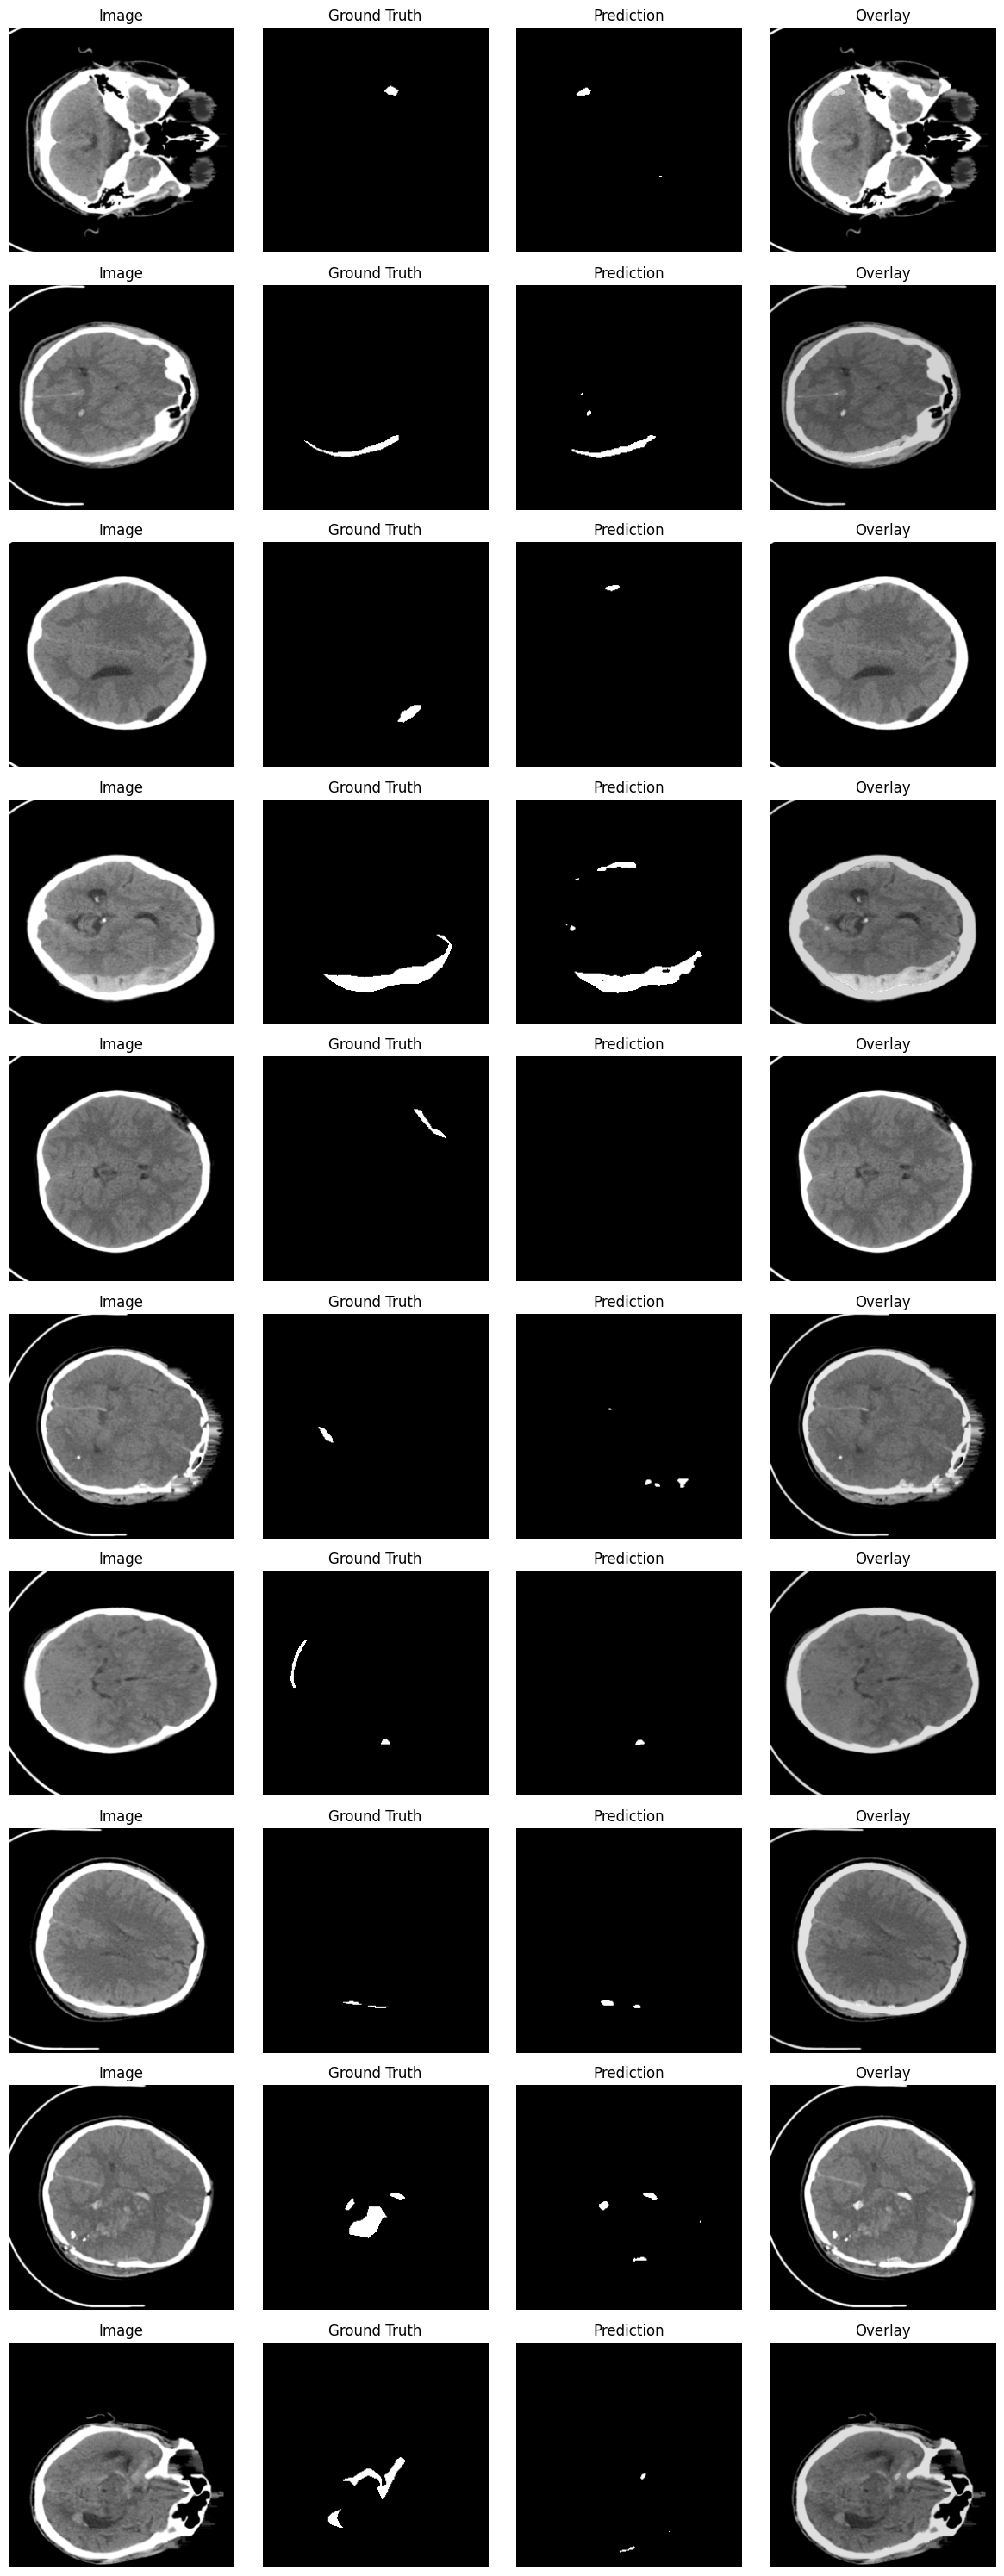

In [125]:
visualize_predictions(model, test_dataset, device)

In [126]:
import numpy as np

total = 0
non_empty = 0

for img in os.listdir(mask_dir):
    m = np.array(Image.open(os.path.join(mask_dir, img)))
    total += 1
    if m.sum() > 0:
        non_empty += 1

print("Total:", total)
print("Non-empty:", non_empty)

Total: 2814
Non-empty: 318


In [127]:
torch.save(model.state_dict(), "ct_segmentation_model.pth")